In [36]:
#Importamos librerías requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Principales_Canales_Limpio.csv')
data

,Mes,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Canal,Citas Programadas
0,"Febrero, 24",329,0,0,22,4,9,0.027356,0.000000,Piso,9
1,"Marzo, 24",19,0,0,13,16,4,0.210526,0.333333,Piso,28
2,"Abril, 24",76,0,0,35,6,10,0.131579,1.428571,Piso,15
3,"Mayo, 24",87,0,0,40,16,1,0.011494,0.125000,Piso,38
4,"Junio, 24",55,0,0,28,60,3,0.054545,0.230769,Piso,78
...,...,...,...,...,...,...,...,...,...,...,...
85,"Marzo, 26",980,618,16,25,36,11,0.011224,0.366667,Digital,78
86,"Abril, 26",834,179,32,35,59,8,0.009592,0.195122,Digital,83
87,"Mayo, 26",667,170,30,35,103,9,0.013493,0.219512,Digital,140
88,"Junio, 26",748,200,28,28,53,7,0.009358,0.200000,Digital,101


In [38]:
# Verificamos la información general del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Mes                90 non-null     str    
 1   Leads              90 non-null     int64  
 2   Efectivos          90 non-null     int64  
 3   SDC                90 non-null     int64  
 4   PDM                90 non-null     int64  
 5   Citas Efectivas    90 non-null     int64  
 6   Ventas             90 non-null     int64  
 7   Conversion         90 non-null     float64
 8   Aporte             90 non-null     float64
 9   Canal              90 non-null     str    
 10  Citas Programadas  90 non-null     int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 9.3 KB


In [39]:
# Identificamos valores nulos por columna
valores_nulos = data.isnull().sum()
valores_nulos

Mes                  0
Leads                0
Efectivos            0
SDC                  0
PDM                  0
Citas Efectivas      0
Ventas               0
Conversion           0
Aporte               0
Canal                0
Citas Programadas    0
dtype: int64

In [40]:
# Identificamos el total de valores nulos del DataFrame
valores_nulos_total = data.isnull().sum().sum()
valores_nulos_total

np.int64(0)

In [41]:
# Separar las variables cuantitativas y cualitativas

cuantitativas = data.select_dtypes(include=['int64', 'float64'])
cualitativas = data.select_dtypes(exclude=['int64', 'float64'])

cuantitativas

,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Citas Programadas
0,329,0,0,22,4,9,0.027356,0.000000,9
1,19,0,0,13,16,4,0.210526,0.333333,28
2,76,0,0,35,6,10,0.131579,1.428571,15
3,87,0,0,40,16,1,0.011494,0.125000,38
4,55,0,0,28,60,3,0.054545,0.230769,78
...,...,...,...,...,...,...,...,...,...
85,980,618,16,25,36,11,0.011224,0.366667,78
86,834,179,32,35,59,8,0.009592,0.195122,83
87,667,170,30,35,103,9,0.013493,0.219512,140
88,748,200,28,28,53,7,0.009358,0.200000,101


<Figure size 1500x800 with 0 Axes>

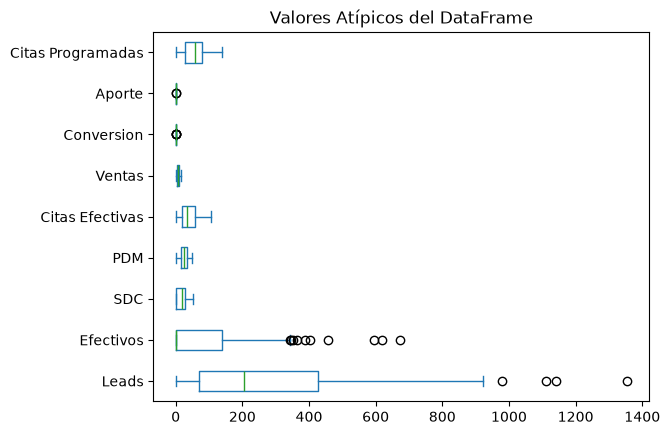

In [42]:
# Realizamos un diagrama de caja para identificar valores atípicos

fig = plt.figure(figsize=(15, 8))

cuantitativas.plot(kind='box', vert=False)

plt.title("Valores Atípicos del DataFrame")
plt.show()

In [43]:
# Método de cuartiles para identificar valores atípicos

y = cuantitativas

percentile25 = y.quantile(0.25)
percentile75 = y.quantile(0.75)

iqr = percentile75 - percentile25

Limite_Superior_iqr = percentile75 + 1.5 * iqr
Limite_Inferior_iqr = percentile25 - 1.5 * iqr

print("Límite Superior Permitido")
print(Limite_Superior_iqr)

print("\nLímite Inferior Permitido")
print(Limite_Inferior_iqr)

Límite Superior Permitido
Leads                956.875000
Efectivos            343.750000
SDC                   70.000000
PDM                   59.625000
Citas Efectivas      117.375000
Ventas                20.500000
Conversion             0.175274
Aporte                 0.616369
Citas Programadas    150.500000
dtype: float64

Límite Inferior Permitido
Leads               -460.125000
Efectivos           -206.250000
SDC                  -42.000000
PDM                  -11.375000
Citas Efectivas      -41.625000
Ventas                -7.500000
Conversion            -0.090098
Aporte                -0.138393
Citas Programadas    -43.500000
dtype: float64


In [44]:
# Identificamos la cantidad de valores atípicos por variable

outliers = (
    (cuantitativas > Limite_Superior_iqr) |
    (cuantitativas < Limite_Inferior_iqr)
)

outliers.sum()

Leads                 4
Efectivos            10
SDC                   0
PDM                   0
Citas Efectivas       0
Ventas                0
Conversion            4
Aporte                2
Citas Programadas     0
dtype: int64

In [45]:
# Mostramos las filas que contienen al menos un valor atípico

indices_outliers = outliers.any(axis=1)

data.loc[indices_outliers]

,Mes,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Conversion,Aporte,Canal,Citas Programadas
1,"Marzo, 24",19,0,0,13,16,4,0.210526,0.333333,Piso,28
2,"Abril, 24",76,0,0,35,6,10,0.131579,1.428571,Piso,15
5,"Julio, 24",92,0,51,35,57,10,0.108696,1.666667,Piso,75
9,"Noviembre, 24",50,0,32,25,14,11,0.220000,0.478261,Piso,18
14,"Abril, 25",43,43,13,28,34,13,0.302326,0.433333,Piso,34
15,"Mayo, 25",65,65,16,34,65,12,0.184615,0.400000,Piso,65
54,"Febrero, 26",433,387,25,39,82,6,0.013857,0.157895,Plazas,105
55,"Marzo, 26",401,364,26,35,55,7,0.017456,0.233333,Plazas,70
56,"Abril, 26",351,351,12,30,31,7,0.019943,0.170732,Plazas,41
57,"Mayo, 26",352,347,18,31,49,7,0.019886,0.170732,Plazas,68


In [46]:
# Identifiqué algunos valores atípicos principalmente en las variables Leads y Efectivos. 
# Al revisar estos datos, observé que la mayoría pertenecen a los canales Digital y Plazas, 
# donde el volumen de leads y contactos efectivos es mayor que en otros canales. 
# Por esta razón decidí conservarlos, ya que no parecen ser errores en los datos, 
# sino diferencias propias del comportamiento de cada canal.

In [47]:
# Separamos el mes y el año
data[['Mes_Nombre', 'Año']] = data['Mes'].str.split(',', expand=True)

data['Mes_Nombre'] = data['Mes_Nombre'].str.strip()
data['Año'] = data['Año'].str.strip().astype(int)

In [48]:
# Convertimos los meses a valores numéricos
meses = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

data['Mes_Num'] = data['Mes_Nombre'].map(meses)

In [49]:
data[['Mes', 'Mes_Num', 'Año']].head(15)

,Mes,Mes_Num,Año
0,"Febrero, 24",2,24
1,"Marzo, 24",3,24
2,"Abril, 24",4,24
3,"Mayo, 24",5,24
4,"Junio, 24",6,24
5,"Julio, 24",7,24
6,"Agosto, 24",8,24
7,"Septiembre, 24",9,24
8,"Octubre, 24",10,24
9,"Noviembre, 24",11,24


In [50]:
# Seleccionamos las variables para el análisis de correlación
variables_analisis = data[
    ['Leads',
     'Efectivos',
     'SDC',
     'PDM',
     'Citas Efectivas',
     'Ventas',
     'Citas Programadas']
]

In [51]:
# Encontramos las correlaciones entre las variables
Corr_Factors = variables_analisis.corr()
Corr_Factors

,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Citas Programadas
Leads,1.000000,0.423940,0.070023,-0.070045,0.102690,0.159394,0.535724
Efectivos,0.423940,1.000000,0.391878,0.286878,0.374175,0.357587,0.509822
SDC,0.070023,0.391878,1.000000,0.624487,0.602317,0.670612,0.554493
PDM,-0.070045,0.286878,0.624487,1.000000,0.707633,0.706275,0.554728
Citas Efectivas,0.102690,0.374175,0.602317,0.707633,1.000000,0.547833,0.833481
Ventas,0.159394,0.357587,0.670612,0.706275,0.547833,1.000000,0.529587
Citas Programadas,0.535724,0.509822,0.554493,0.554728,0.833481,0.529587,1.000000


In [52]:
# Obtenemos el valor absoluto de las correlaciones
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1

,Leads,Efectivos,SDC,PDM,Citas Efectivas,Ventas,Citas Programadas
Leads,1.000000,0.423940,0.070023,0.070045,0.102690,0.159394,0.535724
Efectivos,0.423940,1.000000,0.391878,0.286878,0.374175,0.357587,0.509822
SDC,0.070023,0.391878,1.000000,0.624487,0.602317,0.670612,0.554493
PDM,0.070045,0.286878,0.624487,1.000000,0.707633,0.706275,0.554728
Citas Efectivas,0.102690,0.374175,0.602317,0.707633,1.000000,0.547833,0.833481
Ventas,0.159394,0.357587,0.670612,0.706275,0.547833,1.000000,0.529587
Citas Programadas,0.535724,0.509822,0.554493,0.554728,0.833481,0.529587,1.000000


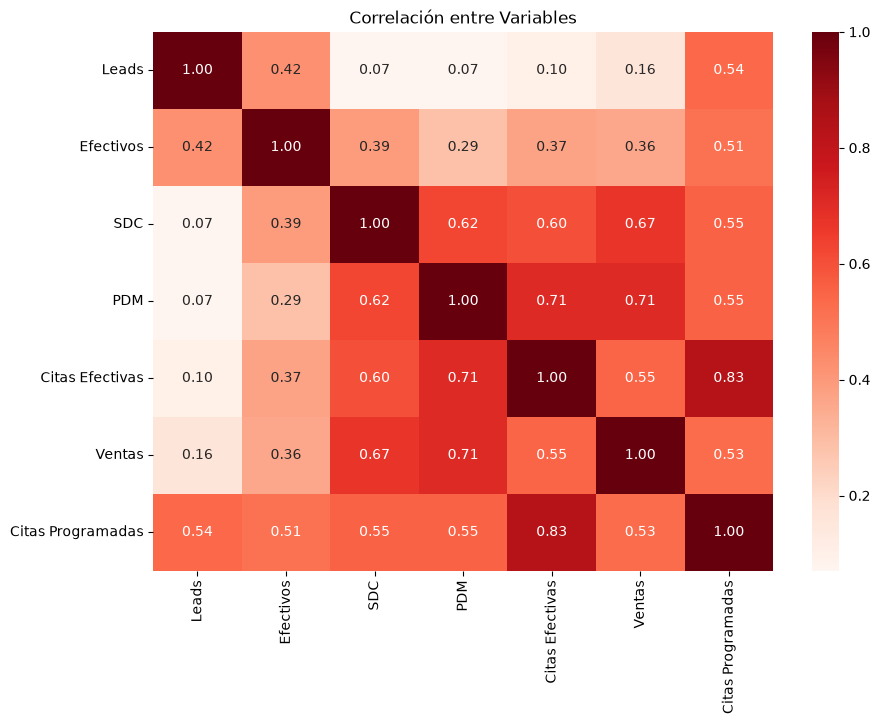

In [55]:
# Graficamos el mapa de calor de las correlaciones

plt.figure(figsize=(10, 7))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap='Reds',
    annot=True,
    fmt=".2f"
)

plt.title("Correlación entre Variables")
plt.show()

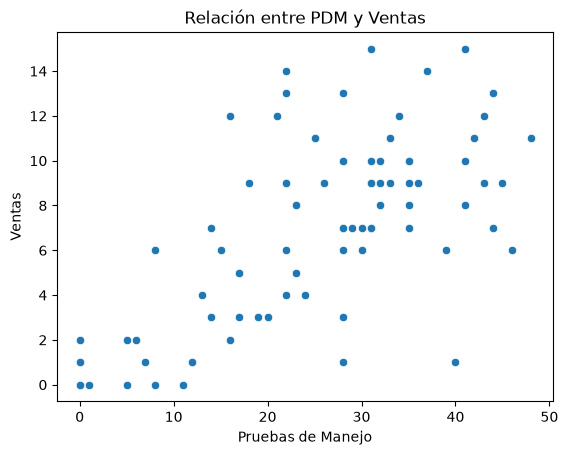

In [ ]:
# Graficamos la dispersión entre PDM y Ventas

sns.scatterplot(x='PDM', y='Ventas', data=data)

plt.title("Relación entre PDM y Ventas")
plt.xlabel("Pruebas de Manejo")
plt.ylabel("Ventas")
plt.show()

In [ ]:
# Declaramos las variables independiente y dependiente

Vars_Indep = data[['PDM']]
Var_Dep = data['Ventas']

In [ ]:
# Importamos la función de regresión lineal

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
# Ajustamos el modelo de regresión lineal

model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.23]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PDM']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.234
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
# Verificamos los coeficientes obtenidos

model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['PDM'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.22761329]),
 'rank_': np.int64(1),
 'singular_': array([124.4282926]),
 'intercept_': np.float64(1.2342961470228548)}

In [ ]:
# Mostramos el intercepto y el coeficiente

print("Intercepto:", model.intercept_)
print("Coeficiente de PDM:", model.coef_[0])

Intercepto: 1.2342961470228548
Coeficiente de PDM: 0.22761328992921


In [ ]:
# Calculamos el coeficiente de determinación R²

coef_Deter = model.score(
    X=Vars_Indep,
    y=Var_Dep
)

coef_Deter

0.4988241503174974

In [ ]:
# Predecimos los valores de Ventas
y_pred = model.predict(X=data[['PDM']])

y_pred

array([ 6.24178853,  4.19326892,  9.20076129, 10.33882774,  7.60746827,
        9.20076129,  8.29030813,  7.60746827,  4.42088221,  6.9246284 ,
        8.51792142,  7.60746827,  8.74553471,  8.51792142,  7.60746827,
        8.973148  ,  8.29030813,  7.83508155, 11.2492809 ,  8.29030813,
       12.15973406, 11.02166761,  6.24178853, 11.70450748,  7.60746827,
       10.56644103,  9.42837458, 11.47689419, 10.79405432,  4.87610879,
        1.23429615,  1.23429615,  1.46190944,  3.73804234,  2.3723626 ,
        2.59997589,  5.10372208,  3.05520247,  2.3723626 ,  5.55894866,
        4.42088221,  6.24178853,  7.60746827,  5.78656195,  6.46940182,
        6.46940182, 11.2492809 ,  9.65598787,  8.06269484, 10.56644103,
       11.02166761,  8.74553471,  5.33133537,  4.6484955 , 10.11121445,
        9.20076129,  8.06269484,  8.29030813, 10.56644103,  3.96565563,
        1.23429615,  1.23429615,  1.23429615,  1.23429615,  1.23429615,
        1.23429615,  1.23429615,  3.05520247,  2.82758918,  5.10

In [ ]:
# Agregamos las predicciones al DataFrame
data['Predicciones'] = y_pred

data[['PDM', 'Ventas', 'Predicciones']].head(15)

,PDM,Ventas,Predicciones
0,22,9,6.241789
1,13,4,4.193269
2,35,10,9.200761
3,40,1,10.338828
4,28,3,7.607468
5,35,10,9.200761
6,31,9,8.290308
7,28,6,7.607468
8,14,3,4.420882
9,25,11,6.924628


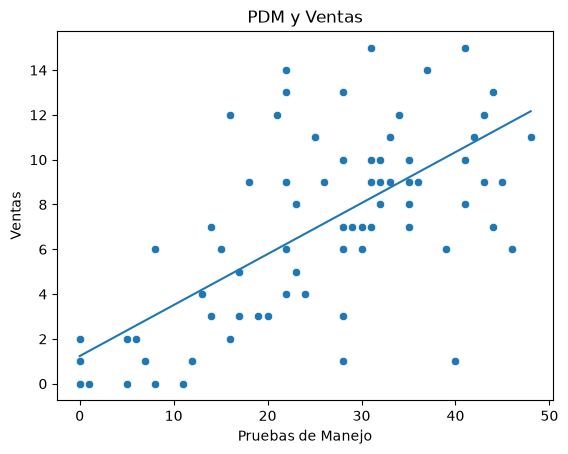

In [ ]:
# Graficamos las ventas reales y las ventas predichas

sns.scatterplot(x='PDM', y='Ventas', data=data)
sns.lineplot(x='PDM', y='Predicciones', data=data)

plt.title("PDM y Ventas")
plt.xlabel("Pruebas de Manejo")
plt.ylabel("Ventas")
plt.show()

In [ ]:
# Calculamos el coeficiente de correlación
coef_Correl = np.sqrt(coef_Deter)
coef_Correl

np.float64(0.7062748404958917)